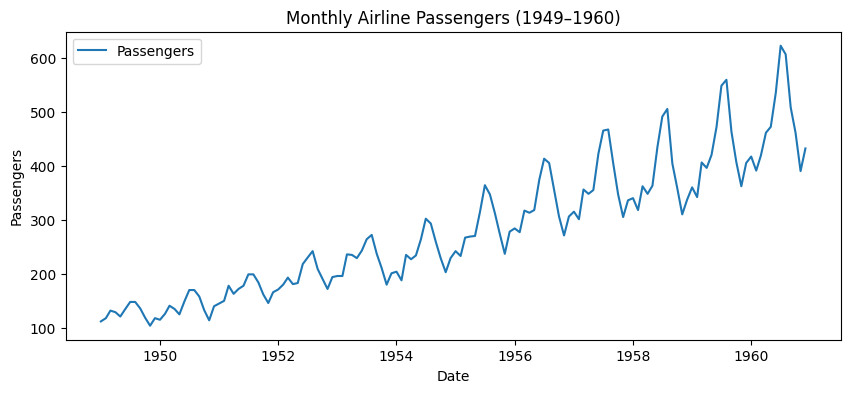

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=["Month"], index_col="Month")

# Plot raw data
plt.figure(figsize=(10,4))
plt.plot(df, label="Passengers")
plt.title("Monthly Airline Passengers (1949–1960)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()

In [4]:
# save df
df.to_csv("airline_passengers.csv")

In [2]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Passengers"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 0.8153688792060463
p-value: 0.991880243437641


p-value > 0.05 → non-stationary.

--> Apply differencing.

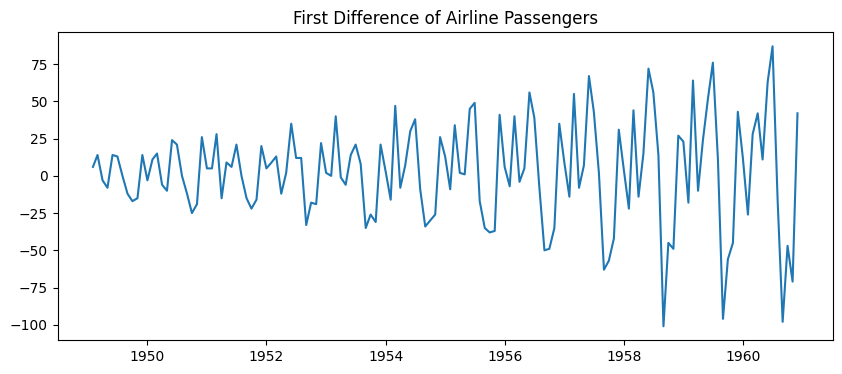

In [3]:
df_diff = df.diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(df_diff, label="Differenced")
plt.title("First Difference of Airline Passengers")
plt.show()

Inspect ACF and PACF

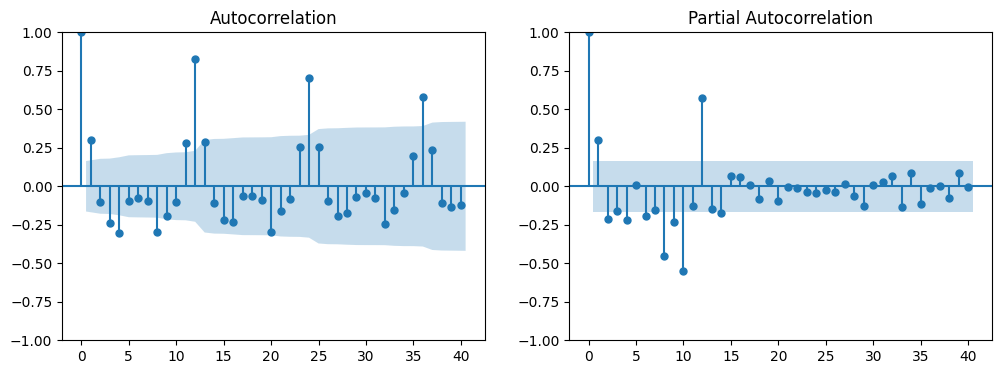

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_acf(df_diff, ax=ax[0], lags=40)
plot_pacf(df_diff, ax=ax[1], lags=40)
plt.show()

ACF shows slow decay → suggests AR terms.

PACF shows cutoff after lag 1 → suggests AR(1).

We might try SARIMA(1,1,1).

4. Fit SARIMA Model

In [5]:
import statsmodels.api as sm

# SARIMA(p,d,q)(P,D,Q, s=12)
sarima_model = sm.tsa.statespace.SARIMAX(
    df["Passengers"],
    order=(1,1,1),           # ARIMA part
    seasonal_order=(1,1,1,12) # seasonal part
).fit()

print(sarima_model.summary())


C:\Users\USR366296\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\USR366296\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -506.149
Date:                            Tue, 02 Sep 2025   AIC                           1022.299
Time:                                    10:56:17   BIC                           1036.675
Sample:                                01-01-1949   HQIC                          1028.140
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1272      0.356     -0.358      0.721      -0.825       0.570
ma.L1         -0.2148      0.325   

Parameters look significant.

Model captures trend + short-term corrections.

5. Diagnose Residuals

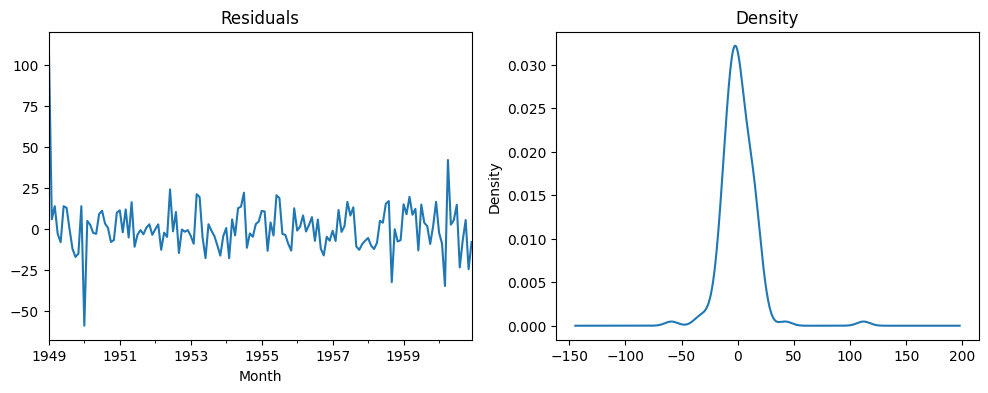

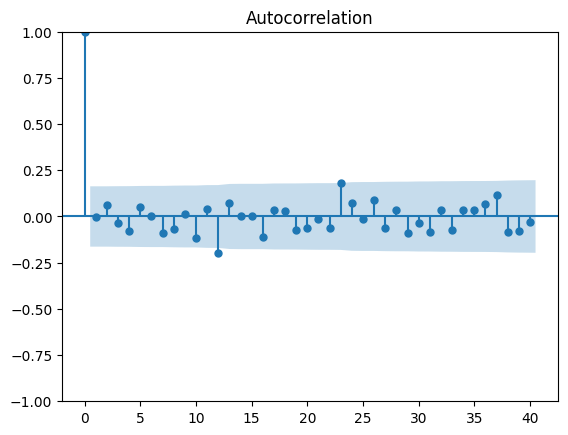

In [7]:
residuals = sarima_model.resid

fig, ax = plt.subplots(1,2, figsize=(12,4))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind="kde", title="Density", ax=ax[1])
plt.show()

sm.graphics.tsa.plot_acf(residuals, lags=40)
plt.show()


Residuals look like white noise.

No strong autocorrelation left → good fit.

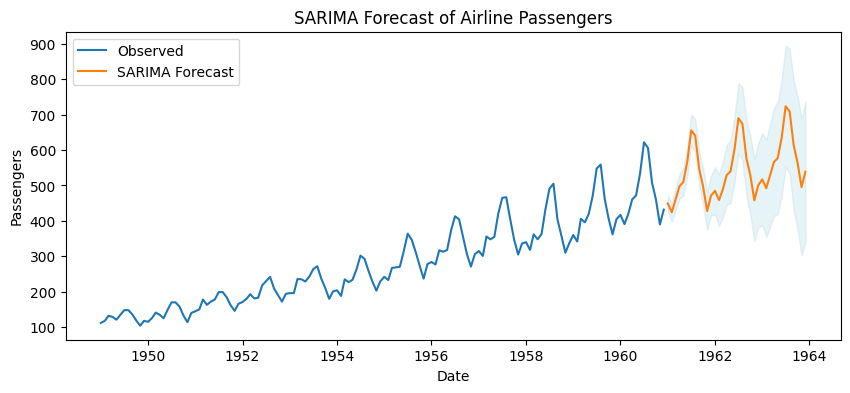

In [8]:
forecast = sarima_model.get_forecast(steps=36)  # 3 years ahead
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(10,4))
plt.plot(df, label="Observed")
plt.plot(forecast_mean.index, forecast_mean, label="SARIMA Forecast")
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:,0],
                 forecast_ci.iloc[:,1], color="lightblue", alpha=0.3)
plt.title("SARIMA Forecast of Airline Passengers")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()


Forecast continues upward trend.

Seasonal pattern is weaker (ARIMA doesn’t explicitly model seasonality; SARIMA would).

Confidence intervals widen over time → reflecting growing uncertainty.